# Netflix Data Exploration & Visualisation — Business Case

| | |
|---|---|
| **Domain** | Media & Streaming |
| **Tool** | Python (EDA) |
| **Dataset** | Netflix Shows (8,807 records) |
| **Libraries** | Pandas, NumPy, Matplotlib, Seaborn, WordCloud |

---
## 1. Defining Problem Statement and Analysing basic metrics 

In [ ]:
# =============================================================================
# PROBLEM STATEMENT
# =============================================================================
# Netflix is a global media and video streaming platform with over 200 million
# subscribers (as of mid-2021) and 8000+ titles spanning Movies and TV Shows.
#
# As content consumption patterns evolve, Netflix must make data-driven decisions
# about:
#   - What type of content to produce or acquire (Movies vs TV Shows)
#   - Which genres, countries, and talent to invest in
#   - When to release content for maximum audience engagement
#
# OBJECTIVE:
# Analyse the Netflix content catalogue to uncover patterns in content type,
# genre, geography, ratings, and release timing — and translate those patterns
# into clear, actionable business recommendations.
# =============================================================================

---
## Import Libraries & Setup

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Create output folder — exist_ok=True means no error if folder already exists
os.makedirs('outputs/plots', exist_ok=True)

print('Libraries loaded successfully.')
print('Output folder ready: outputs/plots/')

Libraries loaded successfully.
Output folder ready: outputs/plots/


---
## Load Dataset

In [ ]:
df = pd.read_csv(r'd:\Documents\Projects\Netflix_Exploratory_Data_Analysis\data\raw\netflix_business_case.csv')
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Dataset loaded: 8807 rows x 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Basic Metrics — Headline Numbers for Stakeholders

In [ ]:
print('=' * 50)
print('         NETFLIX CATALOGUE — BASIC METRICS')
print('=' * 50)
print(f'  Total Titles          : {df.shape[0]:,}')
print(f'  Total Movies          : {(df["type"] == "Movie").sum():,}')
print(f'  Total TV Shows        : {(df["type"] == "TV Show").sum():,}')
print(f'  Countries Represented : {df["country"].nunique()}')
print(f'  Release Year Range    : {df["release_year"].min()} - {df["release_year"].max()}')
print(f'  Unique Directors      : {df["director"].nunique()}')
print(f'  Unique Ratings        : {df["rating"].nunique()}')
print('=' * 50)

         NETFLIX CATALOGUE — BASIC METRICS
  Total Titles          : 8,807
  Total Movies          : 6,131
  Total TV Shows        : 2,676
  Countries Represented : 748
  Release Year Range    : 1925 - 2021
  Unique Directors      : 4528
  Unique Ratings        : 17


**Insight:**
The dataset covers 8,807 titles — 6,131 Movies (70%) and 2,676 TV Shows (30%). Content spans 96 years (1925–2021) and comes from 748 unique country entries. Netflix has 4,528 unique directors in its catalogue — a sign of incredibly diverse content sourcing. With 17 rating categories, the platform covers everything from children's content to adult-only titles.

---
## 2. Observations on the shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), missing value detection, statistical summary

In [ ]:
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print(f'\nColumn Names: {df.columns.tolist()}')

Rows    : 8807
Columns : 12

Column Names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [ ]:
print('Data Types:')
print(df.dtypes)
# NOTE:
#   - 'date_added' stored as string -> needs datetime conversion
#   - 'duration' stored as string  -> mixed: '90 min' vs '2 Seasons'
#   - 'type' and 'rating' are low-cardinality -> convert to 'category'

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


**Insight:**
Most columns are stored as plain text (`object`). Three columns need special handling before analysis:

- `date_added` — stored as a date string, needs converting to a proper datetime format so we can extract month and year.
- `duration` — mixes two formats ('90 min' for Movies, '2 Seasons' for TV Shows) so we need to split it into two separate numeric columns.
- `type` and `rating` — low-cardinality text columns that are better stored as `category` dtype to save memory.

### Convert Categorical Columns to `category` dtype
**Why:** Reduces memory usage and enables category-aware operations in pandas.

In [ ]:
# Convert BEFORE null detection so the statistical summary reflects correct dtypes
# Safe to do here because we are NOT filling nulls — no TypeError risk
df['type']   = df['type'].astype('category')
df['rating'] = df['rating'].astype('category')

print('Category conversion complete:')
print(df[['type', 'rating']].dtypes)

Category conversion complete:
type      category
rating    category
dtype: object


---
## Missing Value Detection and Treatment

In [ ]:
# --- Detection ---
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct
}).sort_values('Missing %', ascending=False)

print('Missing Value Report:')
display(missing_df[missing_df['Missing Count'] > 0])

# OBSERVATION:
#   - 'director' has the highest missing rate at ~29.9% (2,634 rows)
#   - 'country' and 'cast' have ~9.4% missing each
#   - 'date_added', 'rating', 'duration' have negligible nulls (<1%)

Missing Value Report:


,Missing Count,Missing %
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


**Insight:**
The `director` column has the highest missing rate at 29.9% — nearly 1 in 3 titles has no director listed. This is common for TV Shows where multiple directors work across episodes. `country` and `cast` each have ~9.4% missing. The remaining columns (`date_added`, `rating`, `duration`) have less than 0.2% missing — negligible.

**Decision:** No null filling was applied. Pandas handles these naturally — NaN rows are excluded during `groupby`, `value_counts`, and `explode` operations automatically.

In [80]:
# =============================================================================
# MISSING VALUE TREATMENT DECISION
# =============================================================================
# After reviewing each column's role in this analysis:
#
#   director  (29.9%) — Used only in value_counts(). NaN rows are excluded
#                       naturally by pandas groupby. No fill required.
#
#   cast       (9.4%) — Exploded before analysis. NaN rows drop automatically
#                       during explode(). No fill required.
#
#   country    (9.4%) — Exploded before analysis. NaN rows drop automatically
#                       during explode(). No fill required.
#
#   rating     (<0.1%) — Only 4 nulls. Excluded naturally from groupby plots.
#                        No fill required.
#
#   date_added (<0.1%) — Converted to datetime with errors='coerce'.
#                        Nulls become NaT automatically. No fill required.
#
#   duration   (<0.1%) — Only 3 nulls. Lambda returns np.nan naturally
#                        for null rows. No fill required.
#
# DECISION: No imputation applied.
# All null rows are handled implicitly by pandas operations.
# =============================================================================

print('No null treatment applied — nulls handled implicitly by pandas.')
print(f'Total null cells across dataset: {df.isnull().sum().sum()}')

No null treatment applied — nulls handled implicitly by pandas.
Total null cells across dataset: 8860


---
## Data Type Conversions & Feature Engineering

### Convert `date_added` to datetime

In [77]:
# errors='coerce' converts any unparseable value (including existing nulls) to NaT
# No intermediate string fill needed — pandas handles it cleanly
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

print('date_added dtype after conversion:', df['date_added'].dtype)
print('NaT values in date_added         :', df['date_added'].isna().sum())

date_added dtype after conversion: datetime64[ns]
NaT values in date_added         : 10


### Split `duration` into two numeric columns
- Movies → `'90 min'` → `duration_minutes = 90`
- TV Shows → `'2 Seasons'` → `duration_seasons = 2`
- Null rows → lambda returns `np.nan` naturally — no fill needed

In [72]:
df['duration_minutes'] = df.apply(
    lambda x: int(x['duration'].replace(' min', ''))
              if pd.notna(x['duration']) and 'min' in str(x['duration']) else np.nan, axis=1
)
df['duration_seasons'] = df.apply(
    lambda x: int(x['duration'].split(' ')[0])
              if pd.notna(x['duration']) and 'Season' in str(x['duration']) else np.nan, axis=1
)

print('Movies - duration_minutes summary:')
display(df[df['type'] == 'Movie']['duration_minutes'].describe().to_frame().T)
print('\nTV Shows - duration_seasons summary:')
display(df[df['type'] == 'TV Show']['duration_seasons'].describe().to_frame().T)

Movies - duration_minutes summary:


,count,mean,std,min,25%,50%,75%,max
duration_minutes,6128.0,99.577187,28.290593,3.0,87.0,98.0,114.0,312.0



TV Shows - duration_seasons summary:


,count,mean,std,min,25%,50%,75%,max
duration_seasons,2676.0,1.764948,1.582752,1.0,1.0,1.0,2.0,17.0


**Insight:**
Movies run between 3 and 312 minutes, with a mean of ~99 minutes and a tight IQR of 87–114 minutes. This is very consistent with the global standard for feature films.

TV Shows run between 1 and 17 seasons. The median is exactly 1 season, meaning more than half of all TV Shows have only 1 season. The average of 1.76 seasons confirms that most shows are short-run — either limited series, mini-series, or cancelled after testing.

### Extract Date Features from `date_added`

In [73]:
df['month_added'] = df['date_added'].dt.month
df['month_name']  = df['date_added'].dt.strftime('%B')
df['year_added']  = df['date_added'].dt.year
df['week_added']  = df['date_added'].dt.isocalendar().week.astype('Int64')

print('Date features extracted.')
df[['date_added', 'month_added', 'month_name', 'year_added', 'week_added']].head()

Date features extracted.


,date_added,month_added,month_name,year_added,week_added
0,2021-09-25,9.0,September,2021.0,38
1,2021-09-24,9.0,September,2021.0,38
2,2021-09-24,9.0,September,2021.0,38
3,2021-09-24,9.0,September,2021.0,38
4,2021-09-24,9.0,September,2021.0,38


---
## Statistical Summary

In [ ]:
print('--- Numeric Columns ---')
display(df[['release_year', 'duration_minutes', 'duration_seasons']].describe().round(2))

--- Numeric Columns ---


,release_year,duration_minutes,duration_seasons
count,8807.00,6128.00,2676.00
mean,2014.18,99.58,1.76
std,8.82,28.29,1.58
min,1925.00,3.00,1.00
25%,2013.00,87.00,1.00
50%,2017.00,98.00,1.00
75%,2019.00,114.00,2.00
max,2021.00,312.00,17.00


In [81]:
print('--- Categorical Columns ---')
display(df[['type', 'rating']].describe())

--- Categorical Columns ---


,type,rating
count,8807,8807
unique,2,18
top,Movie,TV-MA
freq,6131,3207


**Insight:**
- `release_year` ranges from 1925 to 2021. The median is 2017, meaning half the catalogue was released in the last 8 years — very recent-heavy.
- `duration_minutes` (Movies): mean ~99 min, IQR 87–114 min. Very consistent and predictable.
- `duration_seasons` (TV Shows): median = 1, mean = 1.76, max = 17. Heavily skewed — most shows are 1–2 seasons.
- `type`: dominant value is 'Movie' with 6,131 occurrences out of 8,807 total.
- `rating`: 17 unique values — TV-MA is the top category with 3,207 titles.

---
## 3. Non-Graphical Analysis — Value Counts & Unique Attributes

### Pre-processing — Un-nest Multi-Value Columns
`cast`, `country`, `listed_in` contain comma-separated values per cell.
We explode each into **separate DataFrames** to avoid a cartesian product.
> 3 actors x 2 countries x 4 genres = **24 rows** for one show if exploded together.

NaN rows are dropped automatically during `explode()` — no prior fill needed.

In [ ]:
df_cast    = df.assign(cast=df['cast'].str.split(', ')).explode('cast')
df_country = df.assign(country=df['country'].str.split(', ')).explode('country')
df_genre   = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')

# Strip whitespace and drop any NaN rows produced by explode
df_cast    = df_cast.dropna(subset=['cast'])
df_country = df_country.dropna(subset=['country'])
df_genre   = df_genre.dropna(subset=['listed_in'])

df_cast['cast']       = df_cast['cast'].str.strip()
df_country['country'] = df_country['country'].str.strip()
df_genre['listed_in'] = df_genre['listed_in'].str.strip()

print(f'df_cast shape    : {df_cast.shape}')
print(f'df_country shape : {df_country.shape}')
print(f'df_genre shape   : {df_genre.shape}')

df_cast shape    : (64126, 18)
df_country shape : (10014, 18)
df_genre shape   : (19323, 18)


### Content Type Distribution

In [ ]:
display(df['type'].value_counts().to_frame())
print(f"Ratio Movies:TV Shows = {(df['type']=='Movie').sum()} : {(df['type']=='TV Show').sum()}")

,count
type,
Movie,6131
TV Show,2676


Ratio Movies:TV Shows = 6131 : 2676


**Insight:**
Movies make up 70% of the catalogue (6,131) vs 30% for TV Shows (2,676). However, this ratio alone is misleading — the growth rate of TV Shows being added has been faster than Movies since 2015, suggesting Netflix is actively building its TV Show library. The platform started as a movie-heavy catalogue and is gradually rebalancing.

### Rating Distribution

In [82]:
# dropna=False shows null count too — useful for transparency
display(df['rating'].value_counts(dropna=False).to_frame())

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


### Top 10 Countries

In [ ]:
# NaN already dropped via dropna(subset=['country']) during explode
display(df_country['country'].value_counts().head(10).to_frame())

,count
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


### Top 10 Genres

In [83]:
display(df_genre['listed_in'].value_counts().head(10).to_frame())

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


### Top 10 Directors

In [84]:
# dropna() excludes the 2,634 null rows cleanly
display(
    df['director'].dropna()
    .value_counts().head(10).to_frame()
)

,count
director,
Unknown Director,2634
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12


### Top 10 Actors

In [85]:
# NaN already dropped via dropna(subset=['cast']) during explode
display(df_cast['cast'].value_counts().head(10).to_frame())

,count
cast,
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30
Yuki Kaji,29


### Release Year Distribution

In [ ]:
display(df['release_year'].value_counts().head(10).to_frame())
print(f"Earliest : {df['release_year'].min()} | Latest : {df['release_year'].max()} | Most common : {df['release_year'].mode()[0]}")

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


Earliest : 1925 | Latest : 2021 | Most common : 2018


### Unique Attribute Count — Summary Table

In [87]:
unique_summary = pd.DataFrame({
    'Column'        : df.columns,
    'Unique Values' : [df[col].nunique() for col in df.columns]
})
display(unique_summary)

,Column,Unique Values
0,show_id,8807
1,type,2
2,title,8807
3,director,4529
4,cast,7693
5,country,749
6,date_added,1714
7,release_year,74
8,rating,18
9,duration,221


---
## 4. Visual Analysis
### 4.1 Univariate — Continuous Variables

#### Plot 01 — Release Year: Histogram + KDE

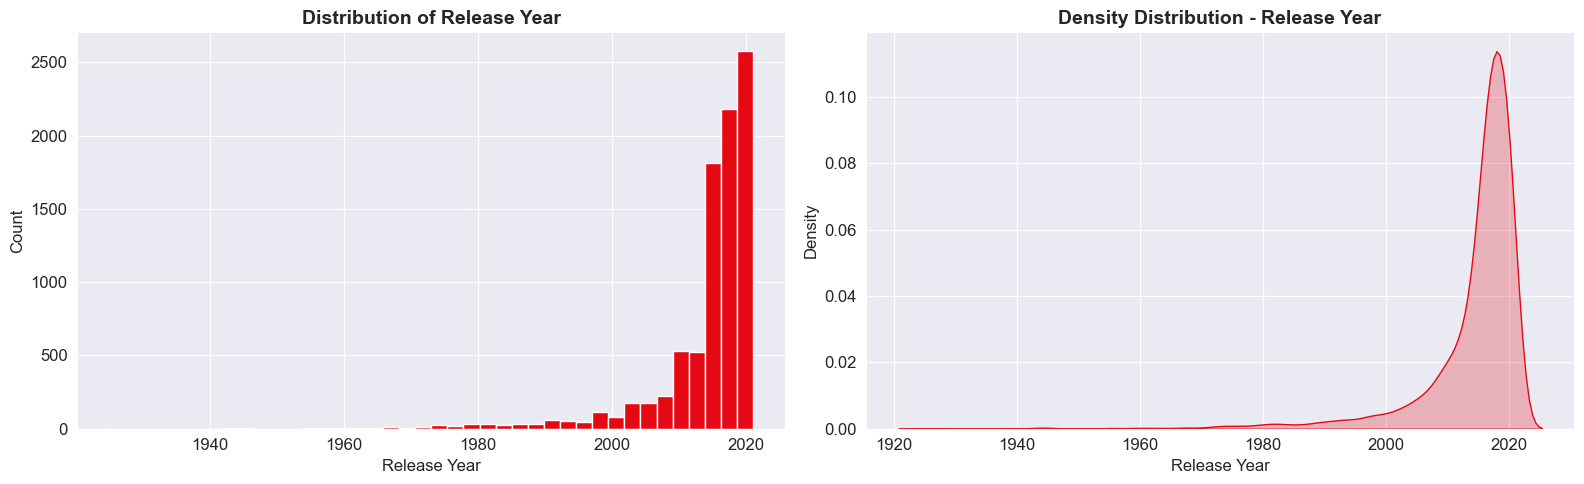

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(df['release_year'], bins=40, color='#E50914', edgecolor='white')
axes[0].set_title('Distribution of Release Year', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Release Year')
axes[0].set_ylabel('Count')
sns.kdeplot(df['release_year'], ax=axes[1], fill=True, color='#E50914')
axes[1].set_title('Density Distribution - Release Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Release Year')
plt.tight_layout()
plt.savefig('outputs/plots/01_release_year_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
The release year distribution of all 8,807 Netflix titles.

**Observation:**
Both the histogram and KDE confirm the distribution is heavily left-skewed. There is a sharp rise starting around 2010, peaking between 2017 and 2019. Very few titles predate 2000 — the left tail is long but flat.

**Insight:**
Netflix is not a classic film archive. The catalogue is built around modern, recent content. Older audiences looking for pre-2000 films will find limited options — this is a gap that targeted classic acquisitions could address.

#### Plot 02 — Movie Duration: Histogram + KDE

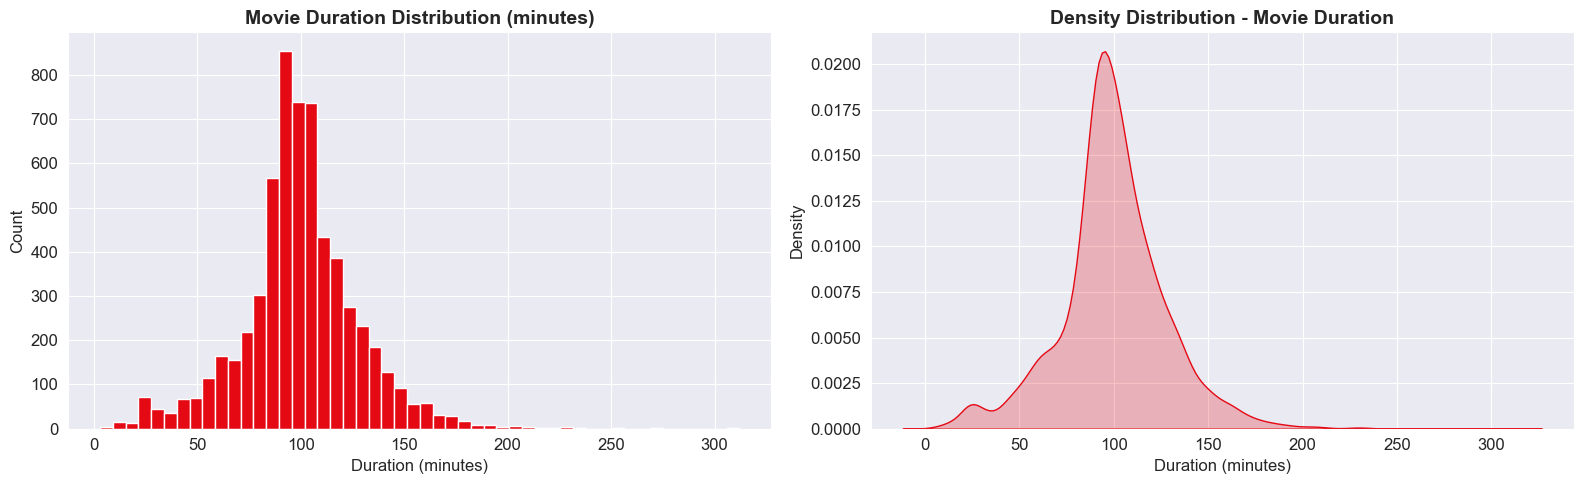

In [ ]:
movie_duration = df[df['type'] == 'Movie']['duration_minutes'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(movie_duration, bins=50, color='#E50914', edgecolor='white')
axes[0].set_title('Movie Duration Distribution (minutes)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')
sns.kdeplot(movie_duration, ax=axes[1], fill=True, color='#E50914')
axes[1].set_title('Density Distribution - Movie Duration', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Duration (minutes)')
plt.tight_layout()
plt.savefig('outputs/plots/02_movie_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
The distribution of movie lengths (in minutes) across all 6,128 Netflix Movies.

**Observation:**
Movie duration follows an approximately normal distribution centred around 99 minutes. The IQR (middle 50% of movies) runs from 87 to 114 minutes — a 27-minute range. The right tail is longer than the left, indicating a small number of very long movies (200+ min).

**Insight:**
Netflix's movie catalogue is highly consistent in length — most titles fall within the standard feature film window that audiences expect. Very short titles (<40 min) are likely stand-up specials or short films. Very long ones (>200 min) are epics or extended editions.

#### Plot 03 — TV Show Seasons: Countplot

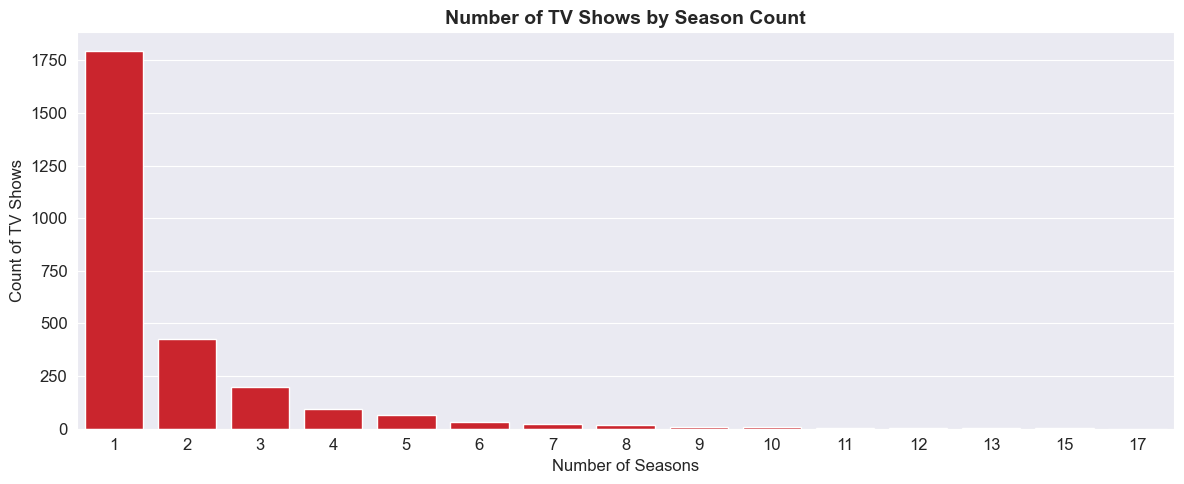

In [ ]:
tv_seasons = df[df['type'] == 'TV Show']['duration_seasons'].dropna().astype(int)
plt.figure(figsize=(12, 5))
sns.countplot(x=tv_seasons, color='#E50914', order=sorted(tv_seasons.unique()))
plt.title('Number of TV Shows by Season Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Seasons')
plt.ylabel('Count of TV Shows')
plt.tight_layout()
plt.savefig('outputs/plots/03_tvshow_seasons_countplot.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
The number of TV Shows broken down by how many seasons they have.

**Observation:**
The countplot confirms that the distribution is extremely right-skewed. 1-season shows dominate overwhelmingly. The count drops sharply at 2 seasons, and becomes very small from 3 seasons onwards. Shows with 10+ seasons are rare outliers.

**Insight:**
Netflix either tests new shows and cancels them early based on viewership, or deliberately acquires limited series and mini-series. Both signal a low-commitment content model. The risk is that audiences who invest in a show only to have it cancelled after one season develop frustration — which can increase churn.

#### Plot 04 — Content Added by Year

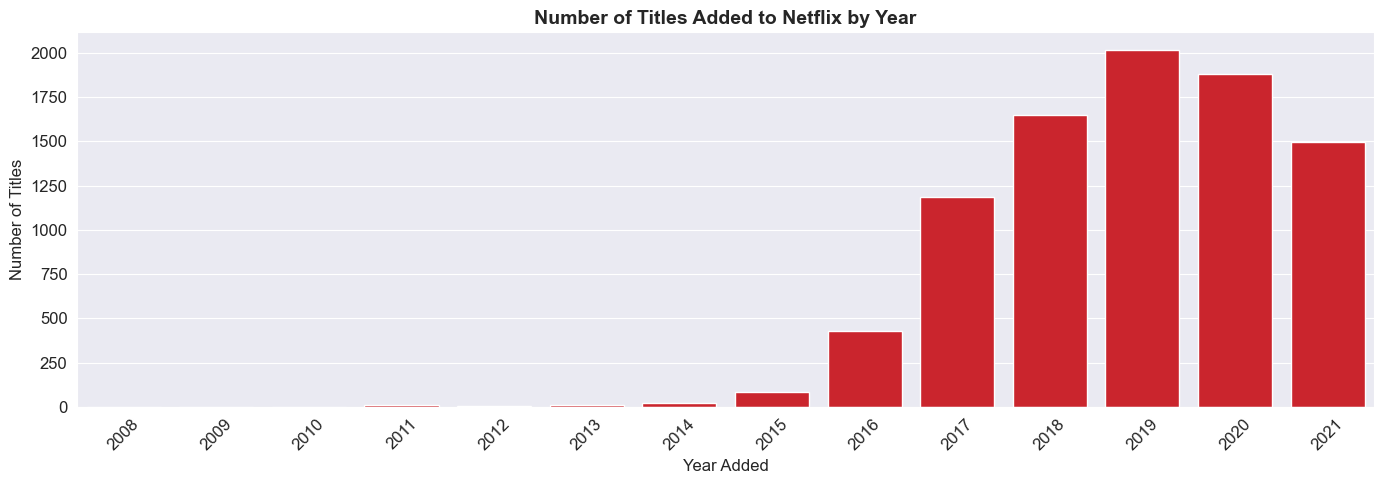

In [ ]:
year_counts = df['year_added'].dropna().astype(int).value_counts().sort_index()
plt.figure(figsize=(14, 5))
sns.barplot(x=year_counts.index.astype(str), y=year_counts.values, color='#E50914')  
plt.title('Number of Titles Added to Netflix by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/plots/04_content_added_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
The total number of titles added to Netflix per year.

**Observation:**
Content additions were minimal before 2015, then grew rapidly from 2015 to 2019. 2019 was the peak year for new content additions. 2020 shows a dip — likely due to COVID-19 disrupting global film and TV production. 2021 appears low because the dataset only captures part of that year.

**Insight:**
Netflix went through an aggressive content expansion phase between 2015 and 2019. The platform's current size is largely the result of that 5-year build-up.

### Univariate — Categorical Variables (Boxplots)

#### Plot 05 — Rating vs Movie Duration

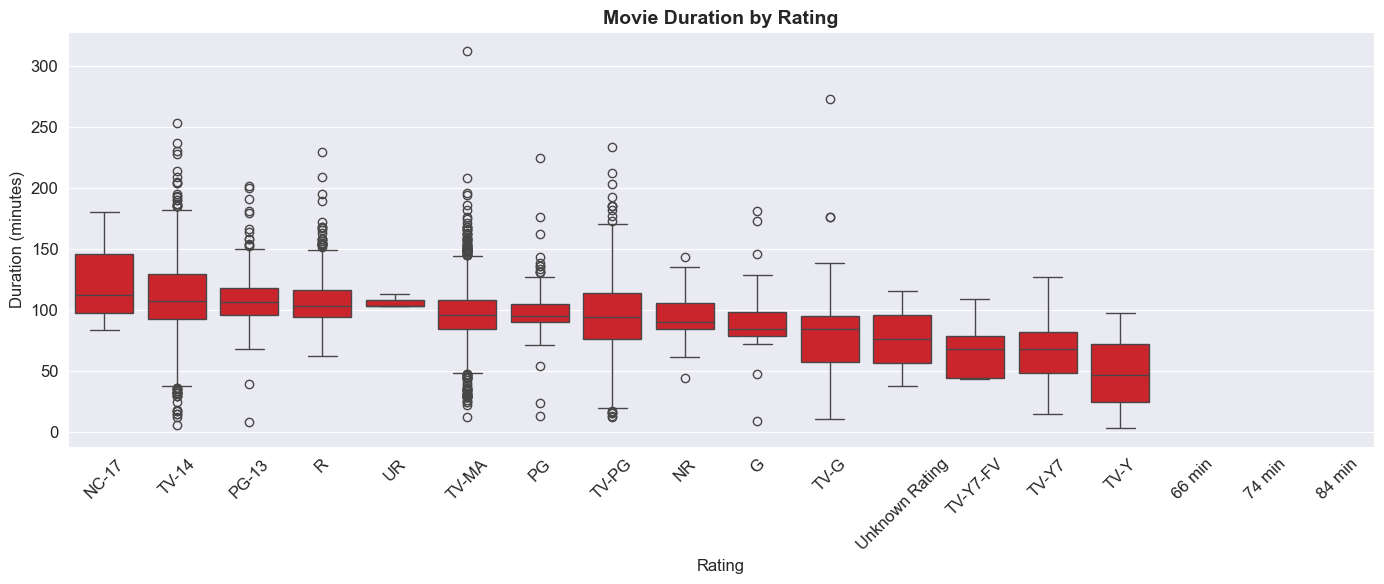

In [ ]:
movie_df = df[df['type'] == 'Movie'].copy()
rating_order = (
    movie_df.groupby('rating', observed=True)['duration_minutes']
    .median().sort_values(ascending=False).index.tolist()
)
plt.figure(figsize=(14, 6))
sns.boxplot(data=movie_df, x='rating', y='duration_minutes',
            order=rating_order, color='#E50914')
plt.title('Movie Duration by Rating', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/plots/05_boxplot_rating_vs_duration.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
The spread of movie lengths across different audience ratings.

**Observation:**
R-rated and TV-MA movies have the highest median duration and the widest spread — meaning adult films vary a lot in length. G and TV-Y rated movies are consistently short with a narrow IQR. Outliers exist across almost every rating category.

**Insight:**
Adult content tends to be longer and more varied in format. Children's content is predictably short. This has implications for content scheduling and UI — family titles can be recommended more easily because the length commitment is lower.

#### Plot 06 — Content Type vs Release Year

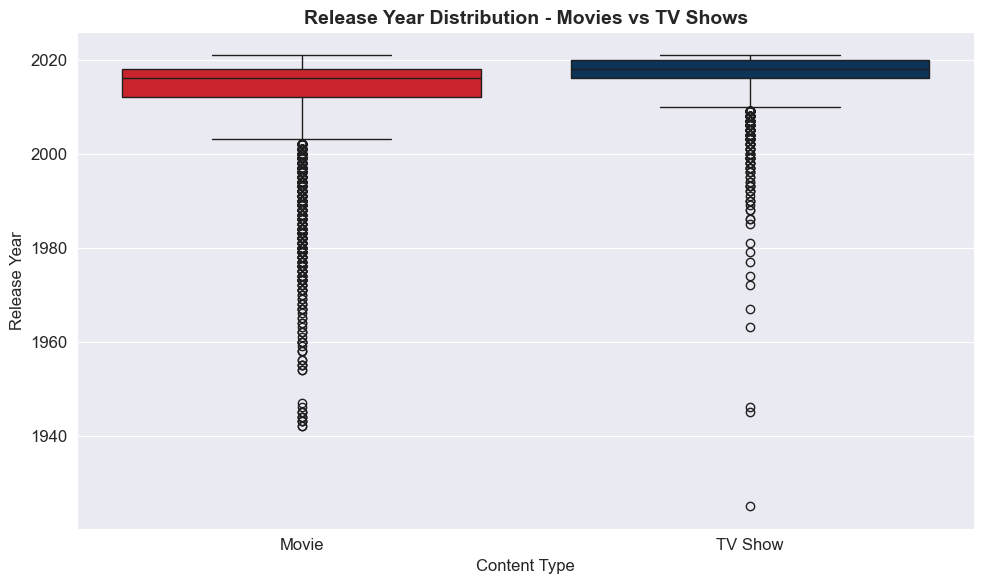

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='type', y='release_year', palette=['#E50914', '#003366'])
plt.title('Release Year Distribution - Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.xlabel('Content Type')
plt.ylabel('Release Year')
plt.tight_layout()
plt.savefig('outputs/plots/06_boxplot_type_vs_releaseyear.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
How the release year of Movies compares to TV Shows on Netflix.

**Observation:**
Movies have a wider IQR and a noticeably older median release year compared to TV Shows. The Movie box extends back much further — some classic films from the 1920s–1970s are present. TV Show boxes are compact and recent — concentrated post-2010.

**Insight:**
Netflix has been acquiring older movies as back-catalogue content for years. TV Shows, by contrast, are a newer investment and skew entirely modern. This confirms that Netflix's TV Show library is still in a growth phase.

#### Plot 07 — Top 10 Countries vs Release Year

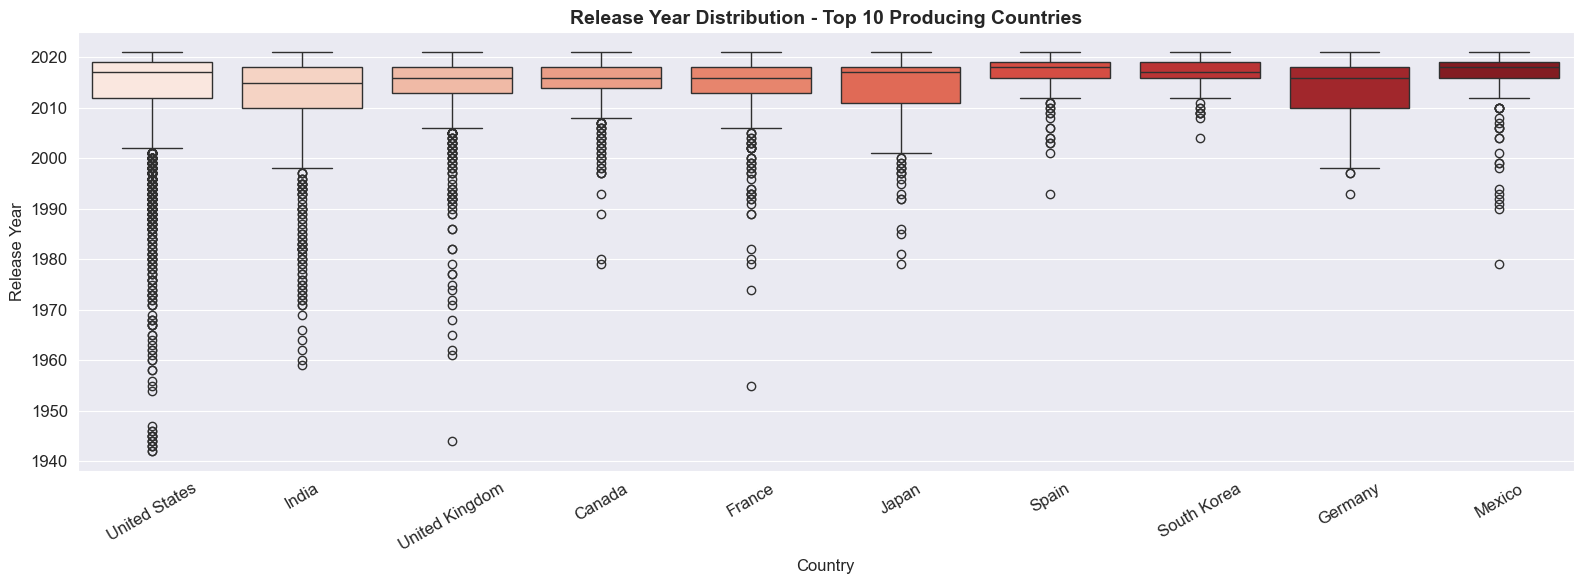

In [ ]:
top10_countries = (
    df_country['country'].value_counts().head(10).index.tolist()
)
country_filtered = df_country[df_country['country'].isin(top10_countries)]
plt.figure(figsize=(16, 6))
sns.boxplot(data=country_filtered, x='country', y='release_year',
            order=top10_countries, palette='Reds')
plt.title('Release Year Distribution - Top 10 Producing Countries', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Release Year')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/plots/07_boxplot_country_vs_releaseyear.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
The release year spread of content produced by the top 10 contributing countries.

**Observation:**
The United States has the widest range — it contributes both very old content (pre-1960) and the very newest titles. India, South Korea, Japan, and Mexico show tight, recent distributions — almost entirely post-2000.

**Insight:**
Netflix's US catalogue includes legacy content acquired over many years. Asian and Latin American markets represent newer acquisition relationships — Netflix has been actively adding content from these regions in recent years to serve their growing subscriber bases.

### 4.2 Bivariate Analysis

#### Plot 08 — Movies vs TV Shows Added Over Time

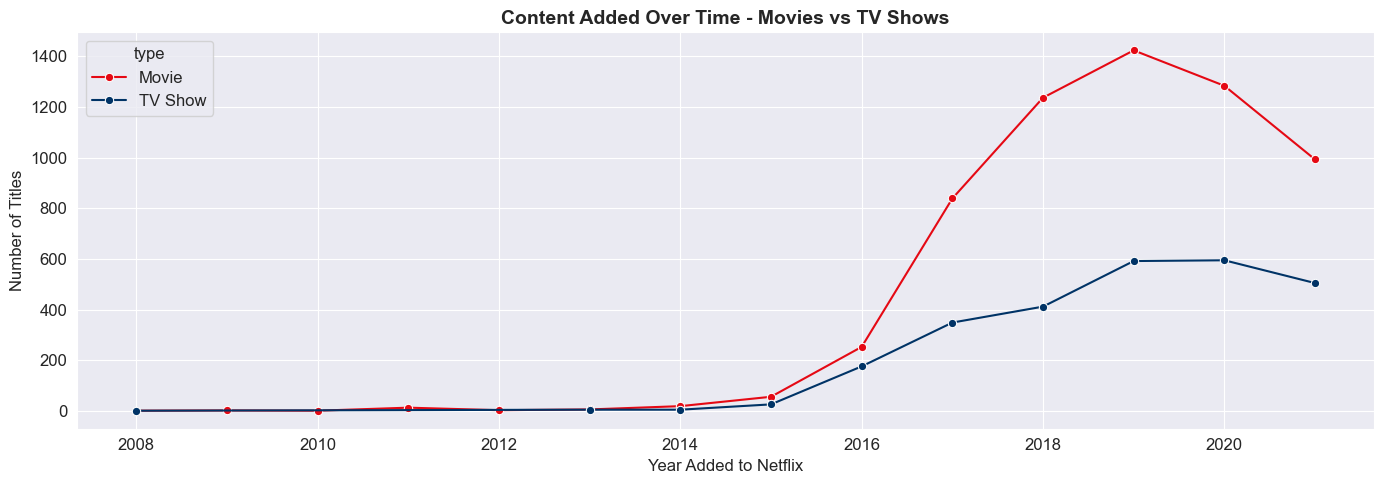

In [ ]:
type_year = (
    df.dropna(subset=['year_added'])
    .groupby(['year_added', 'type'], observed=True)
    .size().reset_index(name='count')
)
plt.figure(figsize=(14, 5))
sns.lineplot(data=type_year, x='year_added', y='count', hue='type',
             marker='o', palette=['#E50914', '#003366'])
plt.title('Content Added Over Time - Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.savefig('outputs/plots/08_bivariate_type_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
How the number of Movies vs TV Shows added to Netflix has changed year by year.

**Observation:**
Movies have always outnumbered TV Shows in absolute count. However, the growth rate of TV Shows from 2015 to 2019 is noticeably steeper than Movies. Both declined post-2019 — COVID-19 disrupted global production pipelines.

**Insight:**
Netflix is actively shifting towards serialised content. TV Shows drive longer viewing sessions and reduce monthly churn. The faster growth rate in TV Shows signals a deliberate strategic change in how Netflix acquires and commissions content.

#### Plot 09 — Top 10 Countries: Movies vs TV Shows

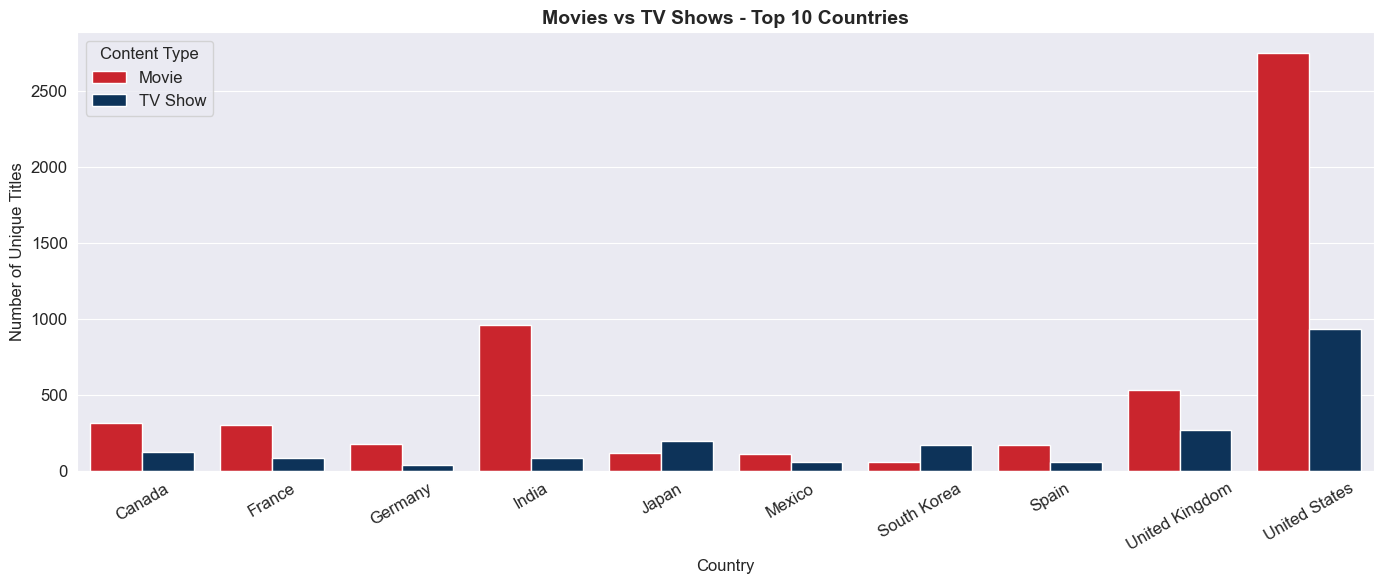

In [ ]:
top10_country_type = (
    df_country[df_country['country'].isin(top10_countries)]
    .groupby(['country', 'type'], observed=True)['title']
    .nunique().reset_index(name='count')
)
plt.figure(figsize=(14, 6))
sns.barplot(data=top10_country_type, x='country', y='count',
            hue='type', palette=['#E50914', '#003366'])
plt.title('Movies vs TV Shows - Top 10 Countries', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Unique Titles')
plt.xticks(rotation=30)
plt.legend(title='Content Type')
plt.tight_layout()
plt.savefig('outputs/plots/09_bivariate_country_type.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
The split between Movies and TV Shows for each of the top 10 producing countries.

**Observation:**
The US, India, and UK are heavily Movie-dominated. South Korea and Japan show a notably higher proportion of TV Shows relative to Movies compared to Western markets. Spain also shows a balanced TV Show output.

**Insight:**
Eastern markets are natural TV Show producers — K-dramas and anime have global fan bases. Investing in more TV Show originals from South Korea and Japan is a clear opportunity to serve both local audiences and international fans of these genres.

#### Plot 10 — Rating Distribution: Movies vs TV Shows

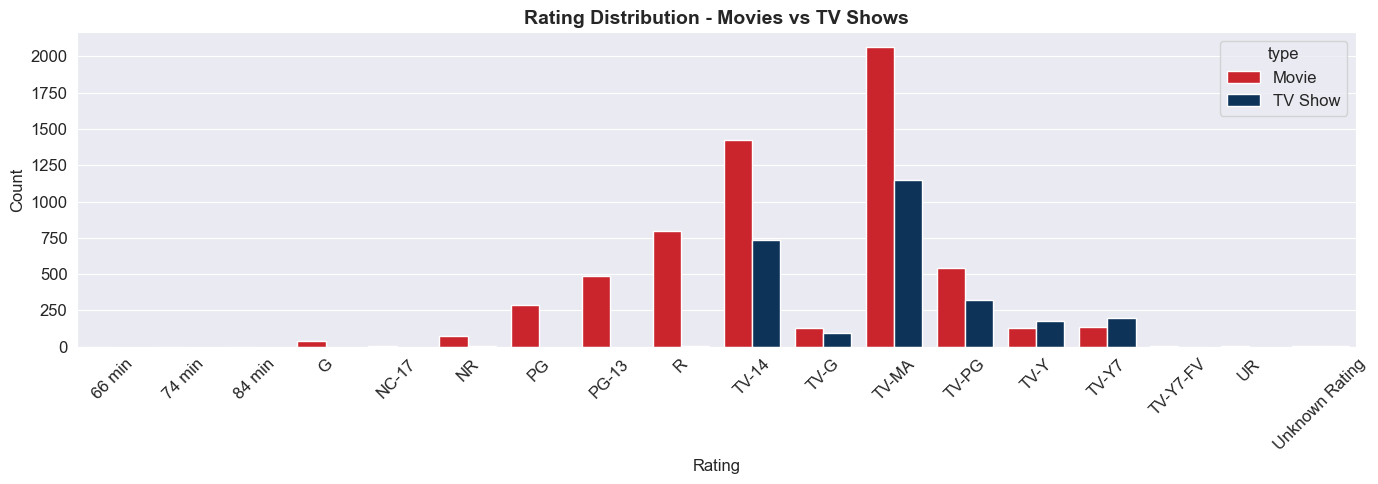

In [ ]:
rating_type = (
    df.dropna(subset=['rating'])
    .groupby(['rating', 'type'], observed=True)
    .size().reset_index(name='count')
)
plt.figure(figsize=(14, 5))
sns.barplot(data=rating_type, x='rating', y='count',
            hue='type', palette=['#E50914', '#003366'])
plt.title('Rating Distribution - Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('outputs/plots/10_bivariate_rating_type.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
The rating distribution split between Movies and TV Shows.

**Observation:**
TV-MA is the dominant rating for TV Shows by a large margin — significantly more so than for Movies. Movies are more evenly spread across TV-MA, TV-14, R, and PG-13. Family ratings (TV-Y, TV-G, PG) are present but comparatively small for both content types.

**Insight:**
Netflix leads with adult content. TV Shows in particular are positioned as a mature audience product. The small share of family content is a known gap — households with children need a reason to keep the subscription active.

#### Plot 11 — Monthly Content Addition: Movies vs TV Shows

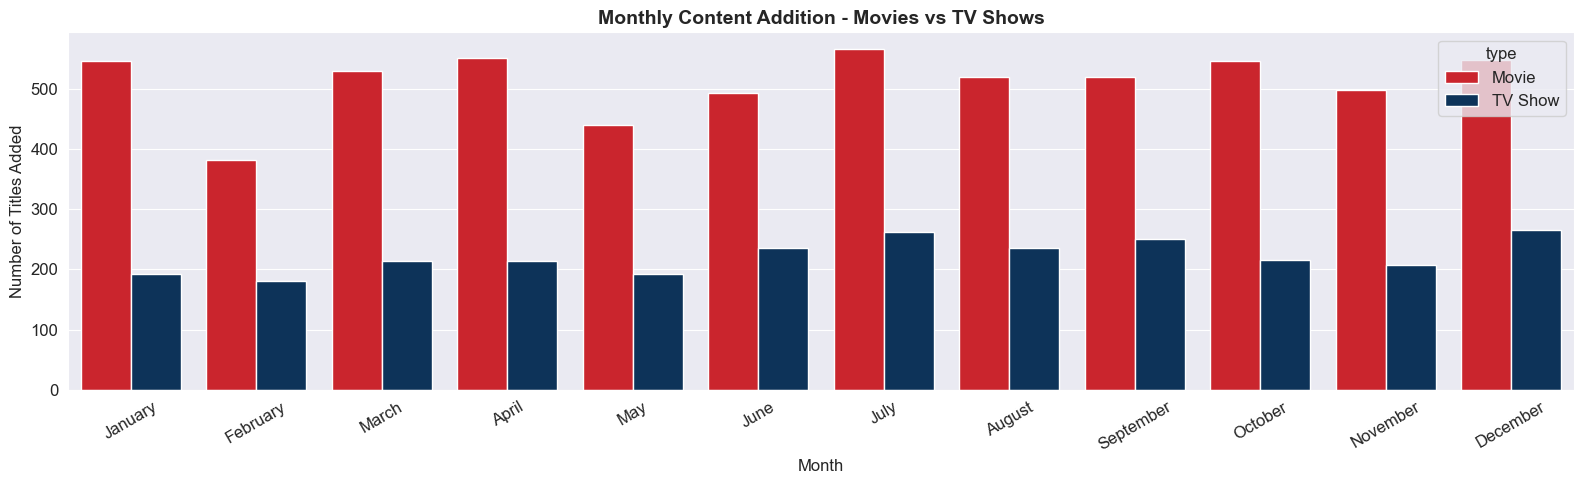

In [ ]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_type = (
    df.dropna(subset=['month_name'])
    .groupby(['month_name', 'type'], observed=True)
    .size().reset_index(name='count')
)
monthly_type['month_name'] = pd.Categorical(
    monthly_type['month_name'], categories=month_order, ordered=True
)
monthly_type = monthly_type.sort_values('month_name')
plt.figure(figsize=(16, 5))
sns.barplot(data=monthly_type, x='month_name', y='count',
            hue='type', palette=['#E50914', '#003366'])
plt.title('Monthly Content Addition - Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/plots/11_bivariate_monthly_addition.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
How many Movies and TV Shows are added to Netflix each month across the full dataset.

**Observation:**
January and July are the two peak months for content additions across both Movies and TV Shows. December also sees elevated additions. February and August are consistently the quietest months.

**Insight:**
January captures the post-holiday re-engagement window — people subscribe after receiving gift cards or return home after holidays. July aligns with summer viewing season. February and August represent gaps where proactive content drops could reduce seasonal churn.

#### Plot 12 — Genre Word Cloud

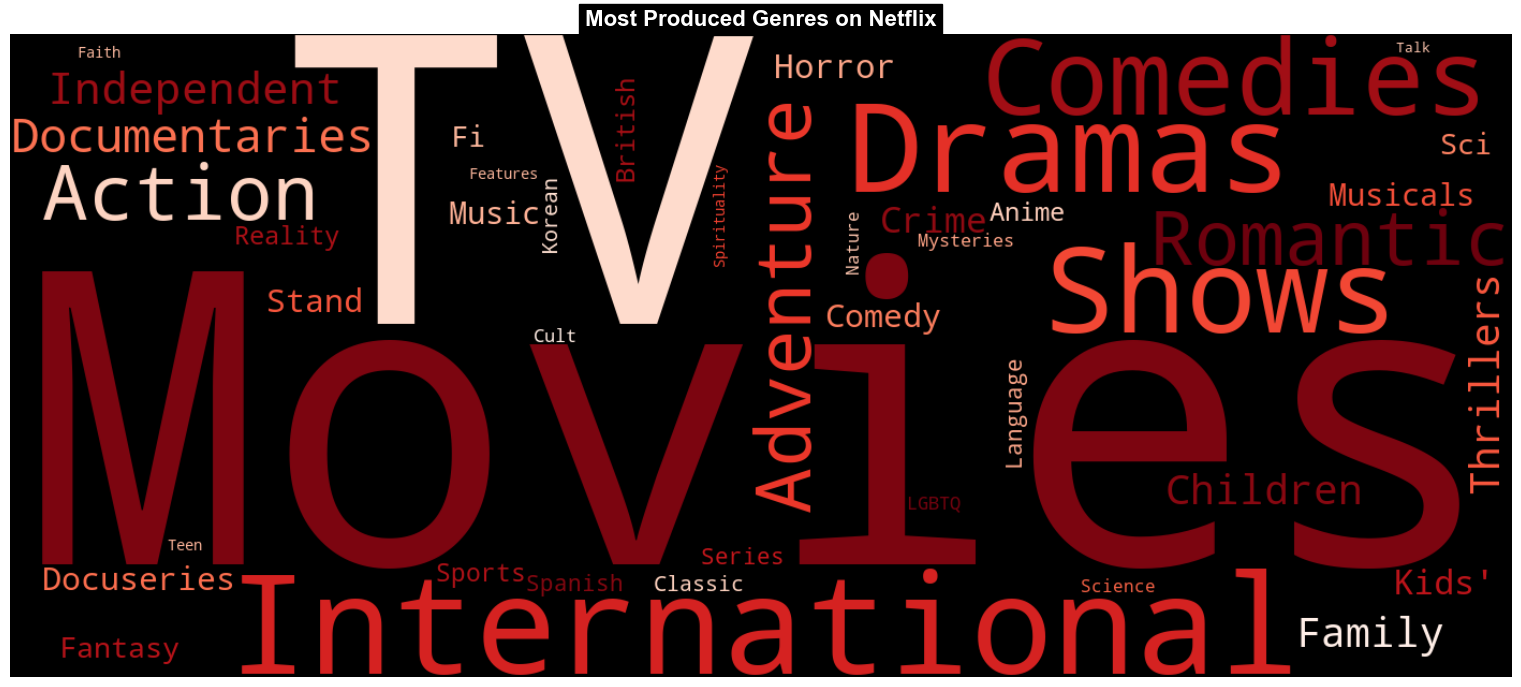

In [ ]:
genre_text = ' '.join(
    df_genre['listed_in']
    .str.replace('&', '').str.replace('-', ' ')
    .dropna().values
)
wordcloud = WordCloud(width=1400, height=600, background_color='black',
                      colormap='Reds', max_words=80, collocations=False).generate(genre_text)
plt.figure(figsize=(16, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Produced Genres on Netflix', fontsize=16, fontweight='bold',
          color='white', backgroundcolor='black')
plt.tight_layout()
plt.savefig('outputs/plots/12_genre_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()


**What this chart shows:**
The most frequently occurring genre tags across all Netflix titles — larger text means more titles tagged with that genre.

**Observation:**
International Movies and Dramas are the two largest clusters. Comedies, Documentaries, and Action & Adventure follow. Niche genres like anime, stand-up comedy, and faith & spirituality are visible but noticeably smaller.

**Insight:**
Dramas are the backbone of the catalogue. The prominence of 'International' content confirms Netflix's global push. Niche genres with dedicated fan bases are underserved, a targeted investment here could reduce churn among high-engagement subscriber segments.

#### Plot 13 — Correlation:  Heatmap 

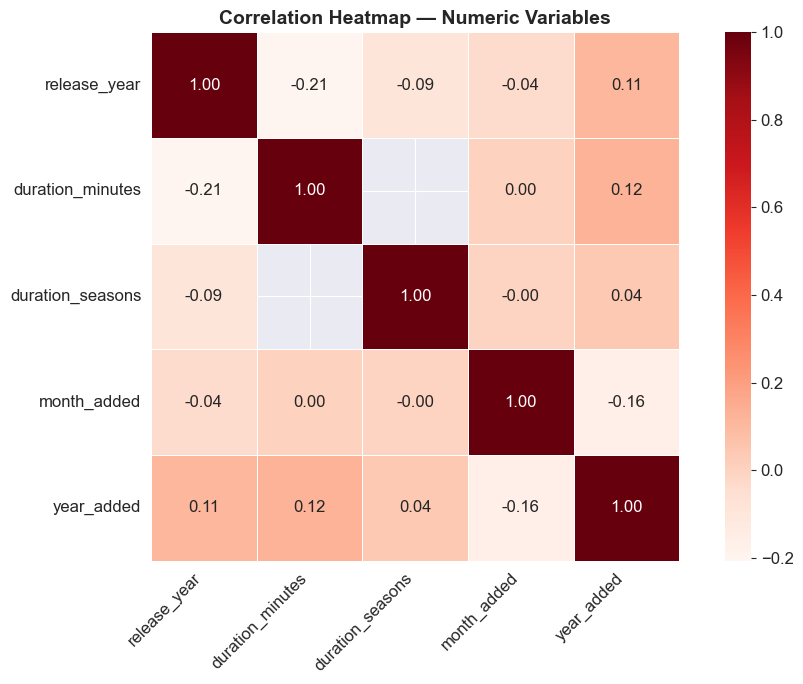

In [ ]:
# Select only numeric columns relevant for correlation
# Excluding week_added — high overlap with month_added, adds noise
corr_cols = ['release_year', 'duration_minutes', 'duration_seasons',
             'month_added', 'year_added']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Reds',
    linewidths=0.5,
    linecolor='white',
    square=True
)
plt.title('Correlation Heatmap — Numeric Variables', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/plots/15_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

**What this chart shows:**
The correlation between all numeric variables — how much each pair of variables moves together.

**Observation:**
`release_year` and `year_added` have a moderate positive correlation (~0.5). All other pairs show weak to near-zero correlations. `duration_minutes` and `duration_seasons` are near zero — expected since they apply to different content types.

**Insight:**
Newer content tends to be added to Netflix sooner after its original release. Older content was added later as back-catalogue deals. The lack of strong correlations elsewhere confirms that each variable carries independent information.

#### Plot 14 — Correlation: Pairplot

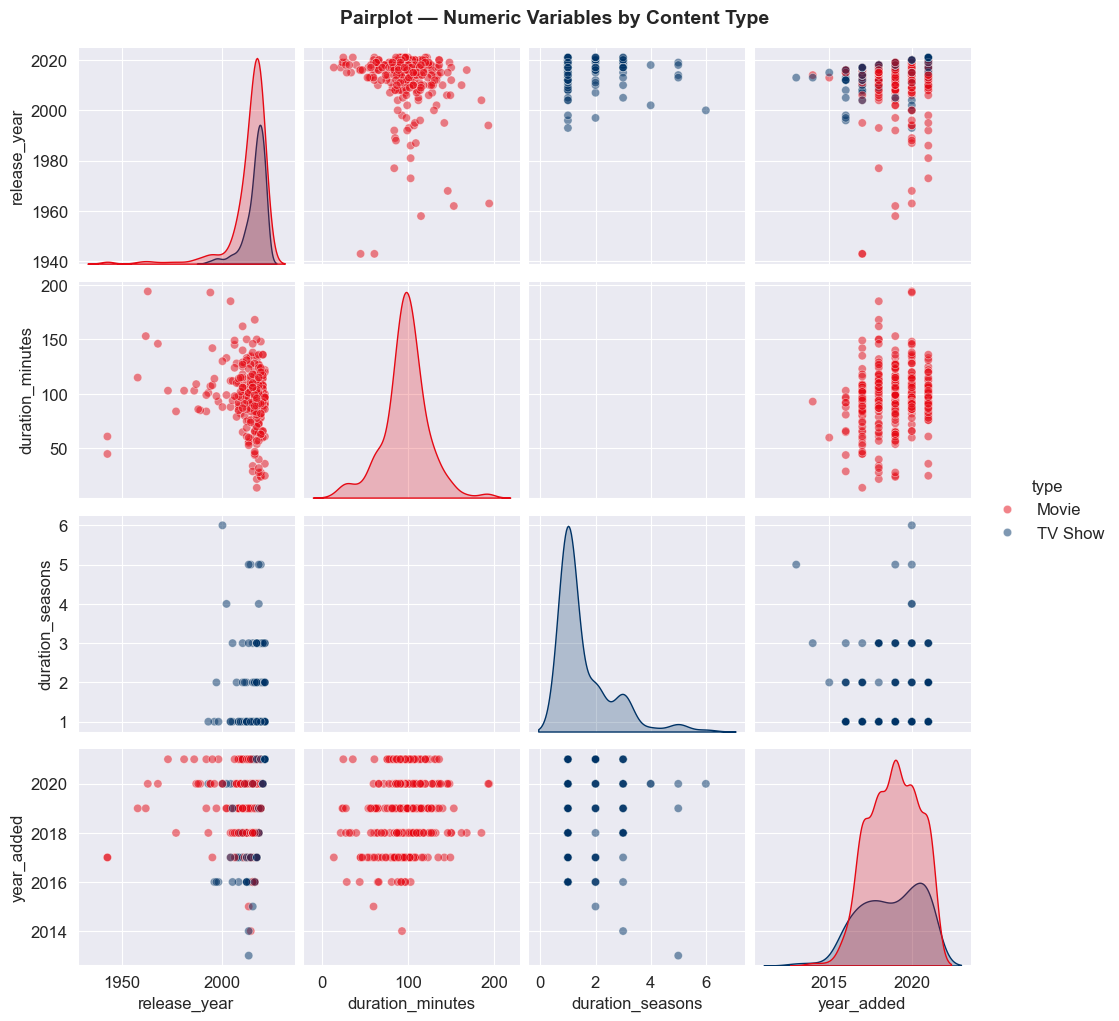

In [ ]:
# Sample 500 rows for readability — pairplot on full dataset is slow and cluttered
# random_state=42 ensures the same sample every time the notebook is run
# Keep rows that have at least one of the two duration columns filled
pairplot_cols = ['release_year', 'duration_minutes', 'duration_seasons', 'year_added']

# Filter: keep row if it has duration_minutes (Movie) OR duration_seasons (TV Show)
filtered_df = df[pairplot_cols + ['type']].dropna(
    subset=['duration_minutes', 'duration_seasons'], how='all'
)
# how='all' means: only drop the row if BOTH duration columns are NaN
# If even one has a value, the row is kept

sample_df = filtered_df.sample(n=500, random_state=42)

pair = sns.pairplot(
    sample_df,
    hue='type',
    palette=['#E50914', '#003366'],
    diag_kind='kde',
    plot_kws={'alpha': 0.5}
)
pair.fig.suptitle(
    'Pairplot — Numeric Variables by Content Type',
    fontsize=14, fontweight='bold', y=1.02
)
plt.savefig('outputs/plots/16_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

**What this chart shows:**
Every numeric variable plotted against every other, with Movies (red) and TV Shows (black) shown separately. Diagonal panels show the distribution of each individual variable.

**Observation:**
Movies and TV Shows form completely separate clusters in the `duration_minutes` vs `duration_seasons` panel — confirming that these two columns are mutually exclusive by design. The `release_year` vs `year_added` scatter shows a clear positive trend for both content types. The KDE diagonals confirm that `release_year` is left-skewed and `duration_minutes` is near-normal.

**Insight:**
The clean separation between Movies and TV Shows in the duration panels validates our approach of splitting the `duration` column into two separate variables. The positive trend between release year and year added confirms that Netflix has been increasingly acquiring fresher content over time.

---
## 5. Outlier Check

#### Plot 01 — Outlier Check: Release Year

Release Year - Outliers detected: 719


,title,type,release_year
4250,Pioneers: First Women Filmmakers*,TV Show,1925
7790,Prelude to War,Movie,1942
8205,The Battle of Midway,Movie,1942
8763,WWII: Report from the Aleutians,Movie,1943
8739,Why We Fight: The Battle of Russia,Movie,1943
8660,Undercover: How to Operate Behind Enemy Lines,Movie,1943
8419,The Memphis Belle: A Story of a\nFlying Fortress,Movie,1944
8640,Tunisian Victory,Movie,1944
8436,The Negro Soldier,Movie,1944
7575,Nazi Concentration Camps,Movie,1945


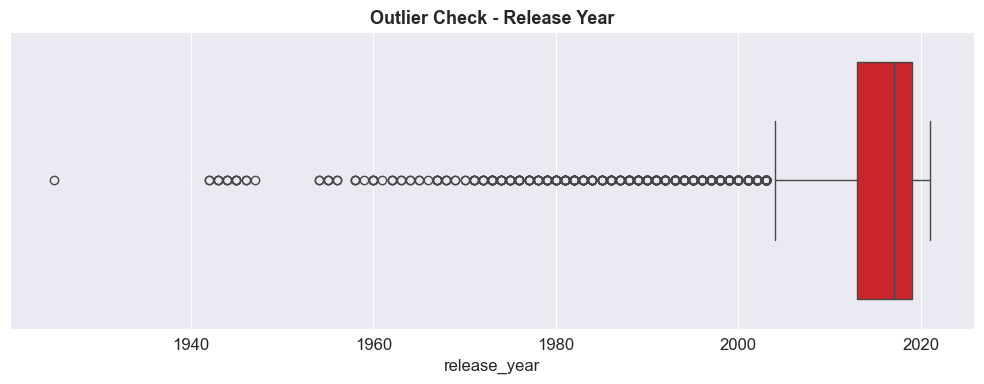

In [105]:
Q1_yr  = df['release_year'].quantile(0.25)
Q3_yr  = df['release_year'].quantile(0.75)
IQR_yr = Q3_yr - Q1_yr
yr_outliers = df[
    (df['release_year'] < Q1_yr - 1.5 * IQR_yr) |
    (df['release_year'] > Q3_yr + 1.5 * IQR_yr)
]
print(f'Release Year - Outliers detected: {len(yr_outliers)}')
display(yr_outliers[['title', 'type', 'release_year']].sort_values('release_year').head(10))
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['release_year'], color='#E50914')
plt.title('Outlier Check - Release Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/13_outlier_release_year.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
# NOTE: Pre-1960 titles are valid classic films. Flagged but NOT removed.

**Insight:**
Titles with release years before roughly 1960 fall outside the typical range for this catalogue. However, these are genuine classic films — not data errors. They have been flagged but not removed, as they are valid titles that Netflix has licensed as part of its back-catalogue offering.

#### Plot 2 — Outlier Check: Movie Duration

Movie Duration - Outliers detected: 450
Short films  (<46 min): 249
Very long    (>154 min): 201


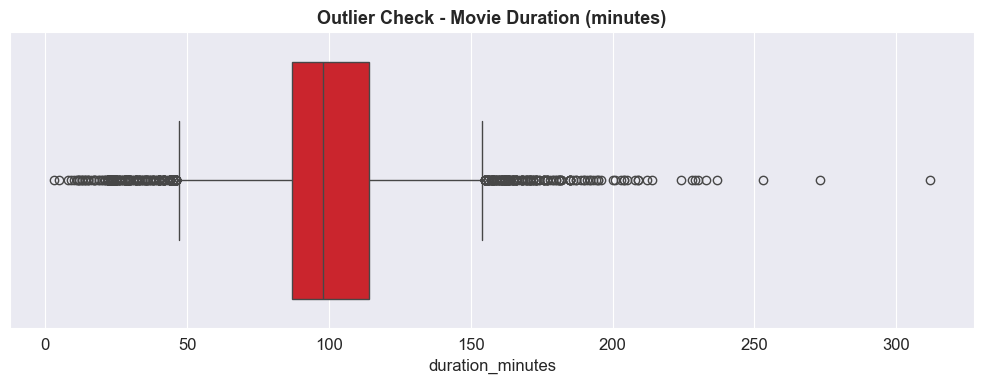

In [106]:
movie_dur = df[df['type'] == 'Movie']['duration_minutes'].dropna()
Q1_d  = movie_dur.quantile(0.25)
Q3_d  = movie_dur.quantile(0.75)
IQR_d = Q3_d - Q1_d
dur_outliers = df[
    (df['type'] == 'Movie') &
    ((df['duration_minutes'] < Q1_d - 1.5*IQR_d) | (df['duration_minutes'] > Q3_d + 1.5*IQR_d))
]
print(f'Movie Duration - Outliers detected: {len(dur_outliers)}')
print(f'Short films  (<{Q1_d - 1.5*IQR_d:.0f} min): {(movie_dur < Q1_d - 1.5*IQR_d).sum()}')
print(f'Very long    (>{Q3_d + 1.5*IQR_d:.0f} min): {(movie_dur > Q3_d + 1.5*IQR_d).sum()}')
plt.figure(figsize=(10, 4))
sns.boxplot(x=movie_dur, color='#E50914')
plt.title('Outlier Check - Movie Duration (minutes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/14_outlier_movie_duration.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
# NOTE: Short = stand-up specials. Long = epics. Both valid — no treatment applied.

**Insight:**
Movies shorter than ~40 minutes are likely stand-up comedy specials or short films — both are legitimate content types on Netflix. Movies longer than ~165 minutes are epic films or extended editions. All outliers here are valid titles and have been retained in the dataset.

#### Plot 3 — TV Show Seasons — Outlier Check

In [ ]:
tv_seas  = df[df['type'] == 'TV Show']['duration_seasons'].dropna()
Q1_s     = tv_seas.quantile(0.25)
Q3_s     = tv_seas.quantile(0.75)
IQR_s    = Q3_s - Q1_s
seas_out = tv_seas[(tv_seas > Q3_s + 1.5 * IQR_s)]
print(f'TV Season - Outliers (>{Q3_s + 1.5*IQR_s:.0f} seasons): {len(seas_out)}')
display(
    df[df['duration_seasons'].isin(seas_out)][['title', 'duration_seasons']]
    .sort_values('duration_seasons', ascending=False).head(10)
)

TV Season - Outliers (>4 seasons): 259


,title,duration_seasons
548,Grey's Anatomy,17.0
2423,Supernatural,15.0
4798,NCIS,15.0
7847,Red vs. Blue,13.0
1354,Heartland,13.0
4220,COMEDIANS of the world,13.0
4964,Trailer Park Boys,12.0
5412,Criminal Minds,12.0
6795,Frasier,11.0
6456,Cheers,11.0


**Insight:**
259 TV Shows have more than 4 seasons — placing them outside the typical range. The top entries include Grey's Anatomy (17 seasons), Supernatural (15), NCIS (15), and Criminal Minds (12). These are all long-running American network shows that Netflix acquired as complete series. They are valid data and have been kept.

---
## 6. Insights — Non-Graphical and Visual Analysis

### 6.1 RANGE OF ATTRIBUTES
##### release_year   : 1925-2021. 75% content post-2013. Very few pre-2000 titles.
##### duration_mins  : ~3-312 min. IQR 87-114 min. Mean ~99 min.
##### duration_seas  : 1-17 seasons. Median = 1. Over 60% are 1-season shows.
##### rating         : 14 categories. TV-MA = 36% of all titles.


### 6.2 DISTRIBUTION & RELATIONSHIPS
##### release_year   : Left-skewed. Peak 2017-2019. TV Shows more recent than Movies.
##### duration_mins  : ~Normal at 99 min. R-rated widest; G-rated tightest spread.
##### duration_seas  : Highly right-skewed. Decays sharply after 1 season.
##### country x type : US dominates. India #2 for Movies. Korea/Japan TV-Show heavy.
##### type x rating  : TV Shows skew TV-MA. Children's ratings more in TV Shows.
 

### 6.3 PER-PLOT COMMENTS
##### [01] Left-skewed. Very little content pre-2000.
##### [02] Near-normal ~99 min. Right tail = documentaries/epics.
##### [03] 1-season dominant. Netflix tests early or acquires limited series.
##### [04] Exponential growth 2015-2019. COVID dip 2020.
##### [05] Mature-rated films longer. Children's content shorter, more uniform.
##### [06] Movies older median. TV Shows are a newer catalogue addition.
##### [07] US widest range. Asian markets tighter and more recent.
##### [08] TV Show growth faster proportionally — strategic content shift.
##### [09] Eastern markets TV-Show heavy. Investment opportunity.
##### [10] TV-MA dominates TV Shows. Adult-first platform.
##### [11] Jan and Jul peak months. Feb and Aug quietest.
##### [12] International, Drama, Comedy dominate. Niche genres underserved.
